<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/MACD/MACD_Single_Stock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Install mplfinance if not already installed
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.2 MB/s eta 0:00:00


In [5]:
import pandas as pd
import yfinance as yf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import mplfinance as mpf
from matplotlib.lines import Line2D

### QQQ Daily Price Chart with MACD Indicator

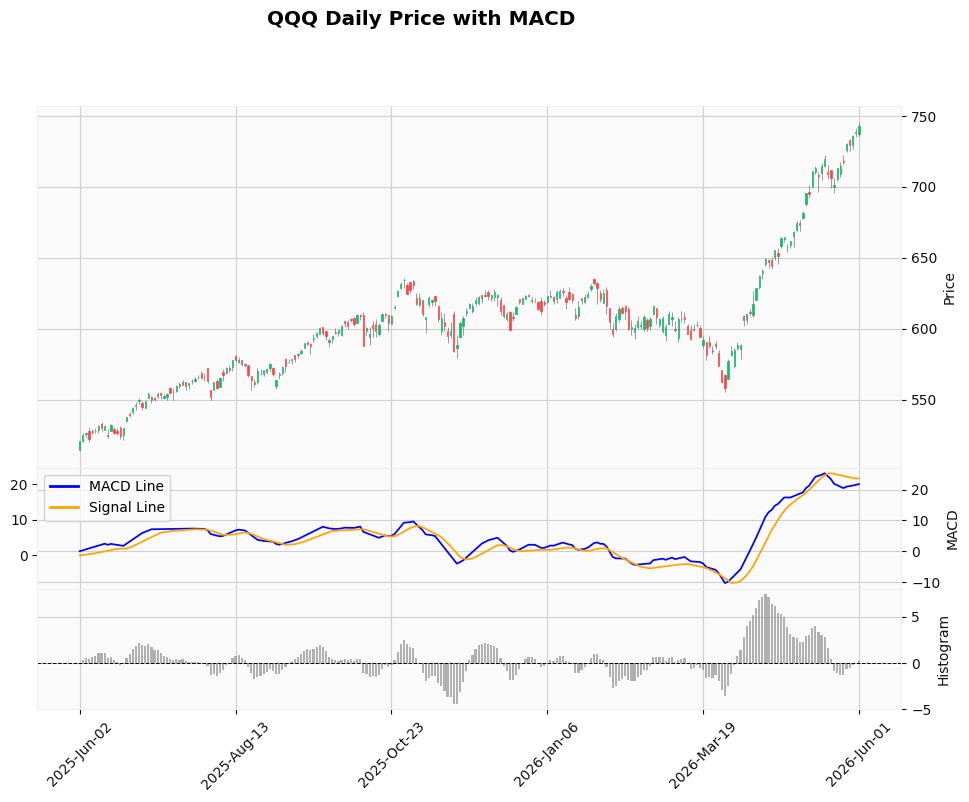

In [20]:

SINGLE_SYMBOL = "QQQ"

# Fetch data for the single symbol
try:
    df_qqq = yf.download(SINGLE_SYMBOL, period="1y", interval="1d", progress=False, auto_adjust=True)
    if df_qqq.empty:
        raise ValueError(f"No data fetched for {SINGLE_SYMBOL}")
    if isinstance(df_qqq.columns, pd.MultiIndex):
        df_qqq.columns = df_qqq.columns.get_level_values(0)

    # --- Calculate Parameterized MACD for QQQ ---
    MACD_FAST_LENGTH = 12
    MACD_SLOW_LENGTH = 26
    MACD_SIGNAL_LENGTH = 9

    df_qqq['EMA_Fast'] = df_qqq['Close'].ewm(span=MACD_FAST_LENGTH, adjust=False).mean()
    df_qqq['EMA_Slow'] = df_qqq['Close'].ewm(span=MACD_SLOW_LENGTH, adjust=False).mean()
    df_qqq['MACD_Line'] = df_qqq['EMA_Fast'] - df_qqq['EMA_Slow']
    df_qqq['Signal_Line'] = df_qqq['MACD_Line'].ewm(span=MACD_SIGNAL_LENGTH, adjust=False).mean()
    df_qqq['MACD_Hist'] = df_qqq['MACD_Line'] - df_qqq['Signal_Line']

except Exception as e:
    print(f"Error fetching data or calculating MACD for {SINGLE_SYMBOL}: {e}")
    df_qqq = pd.DataFrame() # Ensure df_qqq is defined even on error


if not df_qqq.empty:
    # Define addplots for MACD indicator
    apds = [
        mpf.make_addplot(df_qqq['MACD_Line'], panel=1, color='blue', ylabel='MACD'), # Removed label here
        mpf.make_addplot(df_qqq['Signal_Line'], panel=1, color='orange'), # Removed label here
        mpf.make_addplot(df_qqq['MACD_Hist'], type='bar', panel=2, color='gray', ylabel='Histogram', width=0.7, alpha=0.6)
    ]

    # Plot the chart
    fig, axes = mpf.plot(
        df_qqq,
        type='candle',
        style='yahoo',
        title=f'{SINGLE_SYMBOL} Daily Price with MACD',
        ylabel='Price',
        panel_ratios=(6, 2, 2), # Main chart, MACD lines, MACD histogram
        addplot=apds,
        volume=False, # Volume is not explicitly requested, keeping it off for cleaner view
        figscale=1.5,
        returnfig=True
        # Removed legend_loc as it's an unrecognized kwarg
    )

    # Add a zero line for the MACD Histogram for better visualization
    # The histogram is on panel 2, which corresponds to axes[4] in the fig, axes structure.
    if len(axes) > 4: # Check if axes[4] exists for histogram
        axes[4].axhline(0, color='black', linestyle='--', linewidth=0.7)

    # Manual legend for MACD panel (panel 1, which corresponds to axes[2]) using explicit Line2D objects
    if len(axes) > 2: # Ensure the MACD panel (axes[2]) exists
        # Create explicit Line2D objects for the legend handles.
        # These are not plotted on the chart; they only serve as visual representations in the legend.
        macd_legend_handle = Line2D([0], [0], color='blue', lw=2, label='MACD Line')
        signal_legend_handle = Line2D([0], [0], color='orange', lw=2, label='Signal Line')

        # Add the legend to axes[2] using these handles
        axes[2].legend(handles=[macd_legend_handle, signal_legend_handle], loc='upper left')

    plt.show()
else:
    print(f"DataFrame for {SINGLE_SYMBOL} is empty or MACD calculation failed, cannot plot MACD.")

### MACD Signal Line Crosses Analysis

In [21]:
START_DATE_ANALYSIS = "2020-01-01"

# Fetch data from 2020-01-01
try:
    df_analysis = yf.download(SINGLE_SYMBOL, start=START_DATE_ANALYSIS, end=datetime.now(), progress=False, auto_adjust=True)
    if df_analysis.empty:
        raise ValueError(f"No data fetched for {SINGLE_SYMBOL} from {START_DATE_ANALYSIS}")
    if isinstance(df_analysis.columns, pd.MultiIndex):
        df_analysis.columns = df_analysis.columns.get_level_values(0)

    # Recalculate MACD for the extended dataset
    df_analysis['EMA_Fast'] = df_analysis['Close'].ewm(span=MACD_FAST_LENGTH, adjust=False).mean()
    df_analysis['EMA_Slow'] = df_analysis['Close'].ewm(span=MACD_SLOW_LENGTH, adjust=False).mean()
    df_analysis['MACD_Line'] = df_analysis['EMA_Fast'] - df_analysis['EMA_Slow']
    df_analysis['Signal_Line'] = df_analysis['MACD_Line'].ewm(span=MACD_SIGNAL_LENGTH, adjust=False).mean()
    df_analysis['MACD_Hist'] = df_analysis['MACD_Line'] - df_analysis['Signal_Line']

    # Calculate 5-day future return
    df_analysis['Future_5D_Return'] = df_analysis['Close'].pct_change(5).shift(-5)

except Exception as e:
    print(f"Error fetching data or calculating MACD for {SINGLE_SYMBOL}: {e}")
    df_analysis = pd.DataFrame() # Ensure df_analysis is defined even on error

if not df_analysis.empty:
    print(f"Data loaded and MACD calculated for {SINGLE_SYMBOL} from {START_DATE_ANALYSIS} to {df_analysis.index.max().strftime('%Y-%m-%d')}")
    display(df_analysis.tail())
else:
    print("Could not load data for analysis.")

Data loaded and MACD calculated for QQQ from 2020-01-01 to 2026-06-01


Price,Close,High,Low,Open,Volume,EMA_Fast,EMA_Slow,MACD_Line,Signal_Line,MACD_Hist,Future_5D_Return
Date,,,,,,,,,,,
2026-05-26,730.280029,731.169983,724.159973,725.960022,34254700,709.266618,688.344982,20.921636,21.634704,-0.713068,NaN
2026-05-27,729.450012,733.320007,725.440002,732.960022,35148700,712.371756,691.389799,20.981956,21.504154,-0.522198,NaN
2026-05-28,735.599976,736.599976,726.409973,729.729980,32840000,715.945328,694.664627,21.280701,21.459463,-0.178763,NaN
2026-05-29,738.309998,741.630005,735.250000,737.840027,37541700,719.386046,697.897618,21.488429,21.465257,0.023172,NaN
2026-06-01,742.739990,745.650024,735.989990,737.039978,33727900,722.978961,701.219275,21.759686,21.524142,0.235544,NaN


In [36]:
# Identify MACD Signal line crosses
# A cross occurs when MACD_Line crosses above or below Signal_Line
# We look for the day *after* the actual crossover

df_analysis['MACD_Cross_Above'] = (df_analysis['MACD_Line'].shift(1) < df_analysis['Signal_Line'].shift(1)) & \
                                  (df_analysis['MACD_Line'] > df_analysis['Signal_Line'])
df_analysis['MACD_Cross_Below'] = (df_analysis['MACD_Line'].shift(1) > df_analysis['Signal_Line'].shift(1)) & \
                                  (df_analysis['MACD_Line'] < df_analysis['Signal_Line'])

crosses = df_analysis[df_analysis['MACD_Cross_Above'] | df_analysis['MACD_Cross_Below']].copy()

# Catalog crosses
cross_data = []
for index, row in crosses.iterrows():
    histogram_direction = None
    if row['MACD_Cross_Above']:
        histogram_direction = "Negative to Positive"
    elif row['MACD_Cross_Below']:
        histogram_direction = "Positive to Negative"

    if histogram_direction:
        cross_data.append({
            'Date': index,
            'MACD_Value_at_Cross': row['MACD_Line'],
            'Signal_Value_at_Cross': row['Signal_Line'],
            'Histogram_Direction': histogram_direction,
            'Future_5D_Return': row['Future_5D_Return'] * 100 # Convert to percentage
        })

if cross_data:
    crosses_df = pd.DataFrame(cross_data)
    print(f"Found {len(crosses_df)} MACD Signal line crosses.")
    display(crosses_df.head())
else:
    print("No MACD Signal line crosses found.")

Found 129 MACD Signal line crosses.


,Date,MACD_Value_at_Cross,Signal_Value_at_Cross,Histogram_Direction,Future_5D_Return
0,2020-01-08,-0.053899,-0.075003,Negative to Positive,1.390743
1,2020-01-29,1.386993,1.408862,Positive to Negative,2.889877
2,2020-02-04,1.530333,1.350129,Negative to Positive,1.995884
3,2020-02-24,2.525140,3.288491,Positive to Negative,-2.244944
4,2020-03-26,-9.449551,-10.289663,Negative to Positive,-3.069298


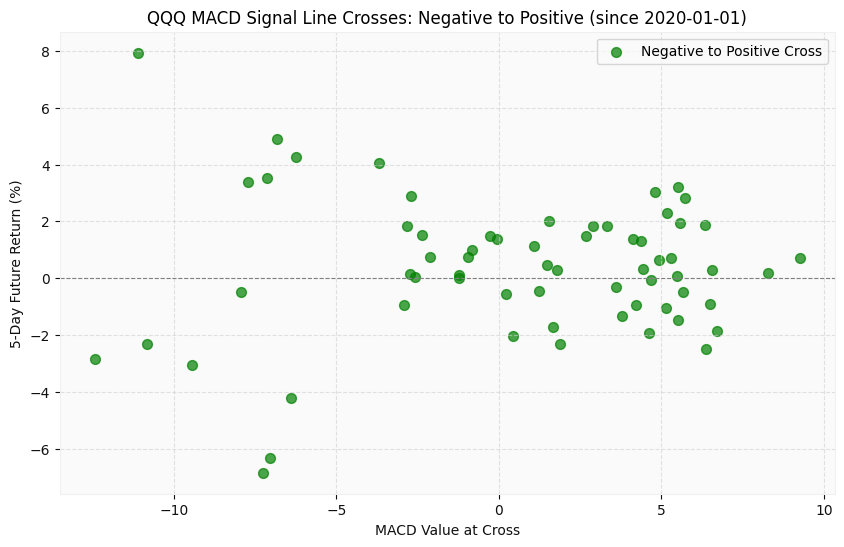

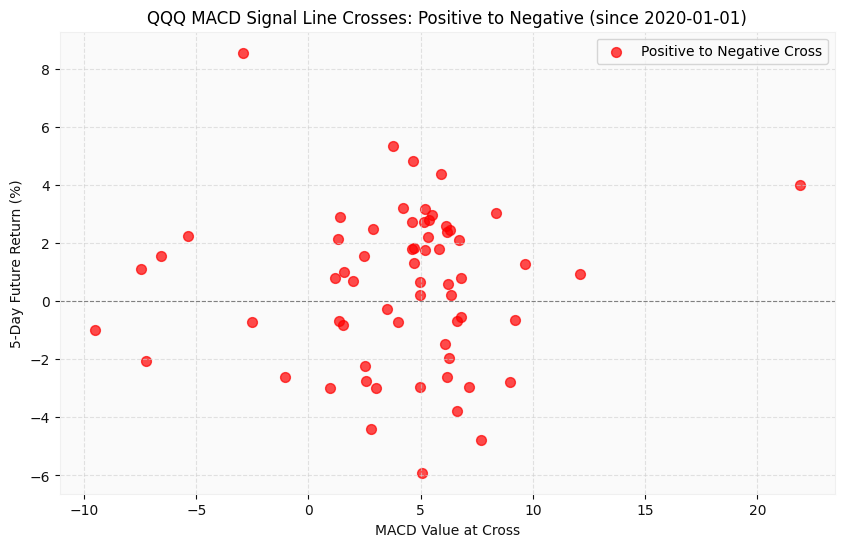

In [24]:
if 'crosses_df' in locals() and not crosses_df.empty:
    df_neg_to_pos = crosses_df[crosses_df['Histogram_Direction'] == 'Negative to Positive']
    df_pos_to_neg = crosses_df[crosses_df['Histogram_Direction'] == 'Positive to Negative']

    # Chart 1: Negative to Positive Crosses
    if not df_neg_to_pos.empty:
        plt.figure(figsize=(10, 6))
        plt.scatter(df_neg_to_pos['MACD_Value_at_Cross'],
                    df_neg_to_pos['Future_5D_Return'],
                    color='green', label='Negative to Positive Cross',
                    alpha=0.7, s=50)
        plt.title(f'{SINGLE_SYMBOL} MACD Signal Line Crosses: Negative to Positive (since {START_DATE_ANALYSIS})')
        plt.xlabel('MACD Value at Cross')
        plt.ylabel('5-Day Future Return (%)')
        plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Zero line for returns
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.show()
    else:
        print("No Negative to Positive crosses data available to plot.")

    # Chart 2: Positive to Negative Crosses
    if not df_pos_to_neg.empty:
        plt.figure(figsize=(10, 6))
        plt.scatter(df_pos_to_neg['MACD_Value_at_Cross'],
                    df_pos_to_neg['Future_5D_Return'],
                    color='red', label='Positive to Negative Cross',
                    alpha=0.7, s=50)
        plt.title(f'{SINGLE_SYMBOL} MACD Signal Line Crosses: Positive to Negative (since {START_DATE_ANALYSIS})')
        plt.xlabel('MACD Value at Cross')
        plt.ylabel('5-Day Future Return (%)')
        plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Zero line for returns
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.show()
    else:
        print("No Positive to Negative crosses data available to plot.")
else:
    print("No cross data available to plot scatter charts.")

### MACD Signal Line Crosses: Win Rate Heatmap

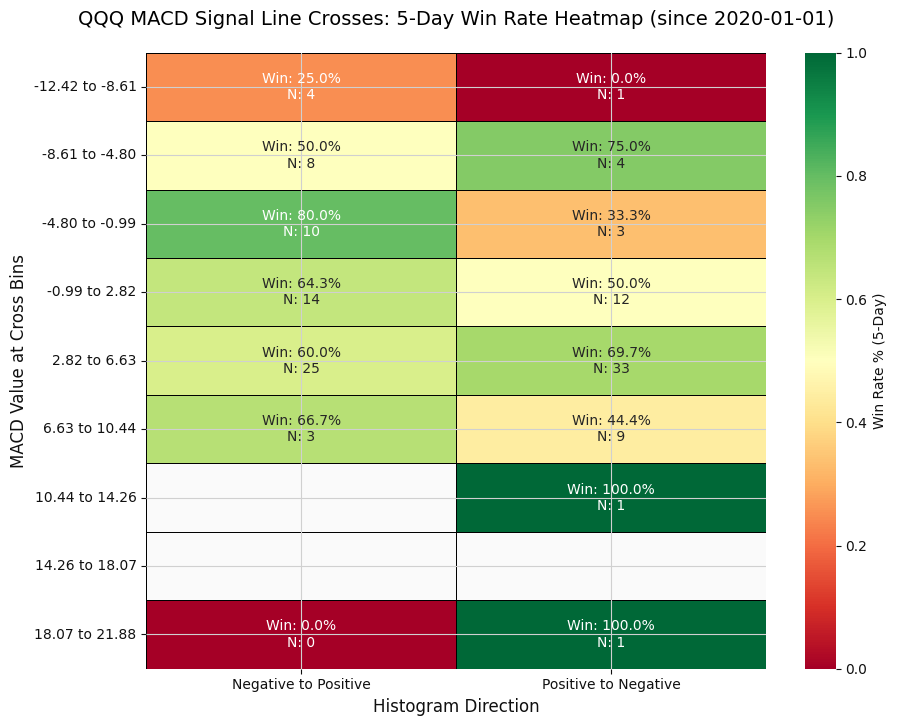

In [33]:
#MACD Signal Line Crosses: Win Rate Heatmap

# Ensure crosses_df exists and is not empty
if 'crosses_df' in locals() and not crosses_df.empty:
    # Create bins for MACD_Value_at_Cross to categorize the data
    # Determine min and max MACD values, and create 10 equally spaced bins
    min_macd = crosses_df['MACD_Value_at_Cross'].min()
    max_macd = crosses_df['MACD_Value_at_Cross'].max()
    # Adjust bin edges to cover the full range and include the min/max values
    bins = np.linspace(min_macd - 0.001, max_macd + 0.001, num=10)
    labels = [f'{bins[i]:.2f} to {bins[i+1]:.2f}' for i in range(len(bins)-1)]

    # Create a CategoricalDtype to ensure all bins are considered even if empty
    all_bins_categories = pd.CategoricalDtype(categories=labels, ordered=True)

    crosses_df['MACD_Value_Bin'] = pd.cut(crosses_df['MACD_Value_at_Cross'], bins=bins, labels=labels, include_lowest=True)

    # Calculate win rate for each bin and histogram direction
    win_rate_analysis = crosses_df.groupby(['Histogram_Direction', 'MACD_Value_Bin'], observed=False).agg(
        Win_Rate=('Future_5D_Return', lambda x: (x > 0).mean()),
        Trade_Count=('Future_5D_Return', 'count')
    ).reset_index()

    # Filter out bins with very few trades to avoid misleading win rates
    # win_rate_analysis = win_rate_analysis[win_rate_analysis['Trade_Count'] >= 5] # Threshold for minimum trades per bin

    if not win_rate_analysis.empty:
        # Pivot the table for heatmap
        heatmap_win_rate = win_rate_analysis.pivot_table(
            index='MACD_Value_Bin',
            columns='Histogram_Direction',
            values='Win_Rate',
            observed=False
        ).reindex(all_bins_categories.categories) # Reindex to ensure all categories are present

        # Pivot the trade count for annotation
        heatmap_trade_count = win_rate_analysis.pivot_table(
            index='MACD_Value_Bin',
            columns='Histogram_Direction',
            values='Trade_Count',
            observed=False
        ).reindex(all_bins_categories.categories) # Reindex to ensure all categories are present

        # Create a custom annotation DataFrame by combining win rate and trade count
        annotations = heatmap_win_rate.apply(
            lambda x: x.index.map(lambda y:
                f"Win: {heatmap_win_rate.loc[y, x.name]:.1%}\nN: {heatmap_trade_count.loc[y, x.name]:.0f}"
                if pd.notna(heatmap_win_rate.loc[y, x.name]) and pd.notna(heatmap_trade_count.loc[y, x.name])
                else ''
            ),
            axis=0
        )

        # Plot the heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            heatmap_win_rate,
            annot=annotations,    # Use the custom annotations
            fmt="",               # No automatic formatting, as annotations are already formatted
            cmap="RdYlGn", # Green for higher win rates, Red for lower
            linewidths=.5, # Add lines between cells
            linecolor='black',
            cbar_kws={'label': 'Win Rate % (5-Day)'}
        )
        plt.title(f'{SINGLE_SYMBOL} MACD Signal Line Crosses: 5-Day Win Rate Heatmap (since {START_DATE_ANALYSIS})', fontsize=14, pad=20)
        plt.xlabel('Histogram Direction', fontsize=12)
        plt.ylabel('MACD Value at Cross Bins', fontsize=12)
        plt.yticks(rotation=0) # Ensure MACD bin labels are horizontal
        plt.show()
    else:
        print("Not enough data after filtering to generate win rate heatmap.")
else:
    print("No cross data available to generate win rate heatmap.")

## Average Return Heatmaps

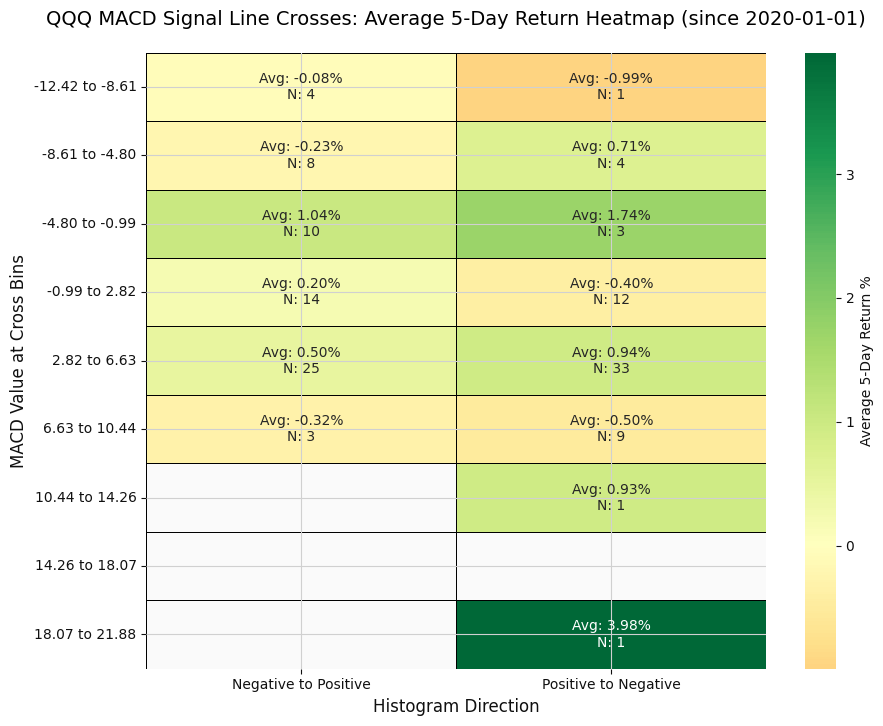

In [37]:
# Average Return Heatmaps

# Ensure crosses_df exists and is not empty
if 'crosses_df' in locals() and not crosses_df.empty:
    # Create bins for MACD_Value_at_Cross to categorize the data
    min_macd = crosses_df['MACD_Value_at_Cross'].min()
    max_macd = crosses_df['MACD_Value_at_Cross'].max()
    # Adjust bin edges to cover the full range and include the min/max values
    bins = np.linspace(min_macd - 0.001, max_macd + 0.001, num=10)
    labels = [f'{bins[i]:.2f} to {bins[i+1]:.2f}' for i in range(len(bins)-1)]

    # Create a CategoricalDtype to ensure all bins are considered even if empty
    all_bins_categories = pd.CategoricalDtype(categories=labels, ordered=True)

    crosses_df['MACD_Value_Bin'] = pd.cut(crosses_df['MACD_Value_at_Cross'], bins=bins, labels=labels, include_lowest=True)

    # Calculate average 5-day return for each bin and histogram direction
    avg_return_analysis = crosses_df.groupby(['Histogram_Direction', 'MACD_Value_Bin'], observed=False).agg(
        Average_5D_Return=('Future_5D_Return', 'mean'),
        Trade_Count=('Future_5D_Return', 'count')
    ).reset_index()

    # Filter out bins with very few trades to avoid misleading averages
    # avg_return_analysis = avg_return_analysis[avg_return_analysis['Trade_Count'] >= 5] # Threshold for minimum trades per bin

    if not avg_return_analysis.empty:
        # Pivot the table for heatmap
        heatmap_data_avg = avg_return_analysis.pivot_table(
            index='MACD_Value_Bin',
            columns='Histogram_Direction',
            values='Average_5D_Return',
            observed=False
        ).reindex(all_bins_categories.categories) # Reindex to ensure all categories are present

        # Pivot the trade count for annotation
        heatmap_trade_count = avg_return_analysis.pivot_table(
            index='MACD_Value_Bin',
            columns='Histogram_Direction',
            values='Trade_Count',
            observed=False
        ).reindex(all_bins_categories.categories) # Reindex to ensure all categories are present

        # Create a custom annotation DataFrame by combining average return and trade count
        annotations_avg_return = heatmap_data_avg.apply(
            lambda x: x.index.map(lambda y:
                f"Avg: {heatmap_data_avg.loc[y, x.name]:.2f}%\nN: {heatmap_trade_count.loc[y, x.name]:.0f}"
                if pd.notna(heatmap_data_avg.loc[y, x.name]) and pd.notna(heatmap_trade_count.loc[y, x.name])
                else ''
            ),
            axis=0
        )

        # Plot the heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            heatmap_data_avg,
            annot=annotations_avg_return,    # Use the custom annotations
            fmt="",               # No automatic formatting, as annotations are already formatted
            cmap="RdYlGn", # Green for higher returns, Red for lower
            center=0,      # Center the colormap at 0% return
            linewidths=.5, # Add lines between cells
            linecolor='black',
            cbar_kws={'label': 'Average 5-Day Return %'}
        )
        plt.title(f'{SINGLE_SYMBOL} MACD Signal Line Crosses: Average 5-Day Return Heatmap (since {START_DATE_ANALYSIS})', fontsize=14, pad=20)
        plt.xlabel('Histogram Direction', fontsize=12)
        plt.ylabel('MACD Value at Cross Bins', fontsize=12)
        plt.yticks(rotation=0) # Ensure MACD bin labels are horizontal
        plt.show()
    else:
        print("Not enough data after filtering to generate average return heatmap.")
else:
    print("No cross data available to generate average return heatmap.")